# Amplificadores (lineal ideal, lineal y conmutado)

Un amplificador es aquel que nos ayuda a aumenta la amplitud de una señal sin alterar su forma. Dependiendo de su diseño y funcionamiento, existen 3 principales amplificadores con características específicas.


### Tipos de amplificadores en la simulación

**Amplificador lineal ideal**
Modelo teórico sin pérdidas ni distorsión.
La señal de salida es una versión amplificada de la entrada sin alteraciones.
Se usa como referencia para comparar el desempeño de amplificadores reales.

**Amplificador lineal**
Presenta pérdidas, saturación y respuesta limitada en frecuencia.
Incluye efectos de la impedancia de entrada y salida.
Refleja el comportamiento de un amplificador en la práctica.

**Amplificador conmutado**
Funciona mediante conmutación rápida entre dos estados (ON/OFF).
Usa modulación de ancho de pulso (PWM) para reconstruir la señal de salida.
Alta eficiencia, pero puede introducir distorsión si no se filtra adecuadamente.

### La simulación de amplificadores nos permite:
- Visualizar el comportamiento de la señal amplificada.
- Comparar diferentes configuraciones y sus efectos.
- Analizar la eficiencia y distorsión de cada tipo de amplificador.

¿Cómo interpretamos la gráfica?
La simulación generará una gráfica donde se comparan las señales de entrada y salida para cada amplificador. Al analizar la curva de salida, podemos observar:

- Ganancia: Cuánto se amplifica la señal.
- Linealidad: Si la salida es proporcional a la entrada.
- Distorsión: Diferencias entre la forma de onda de entrada y salida.
- Eficiencia: Relación entre la potencia de salida y la consumida.

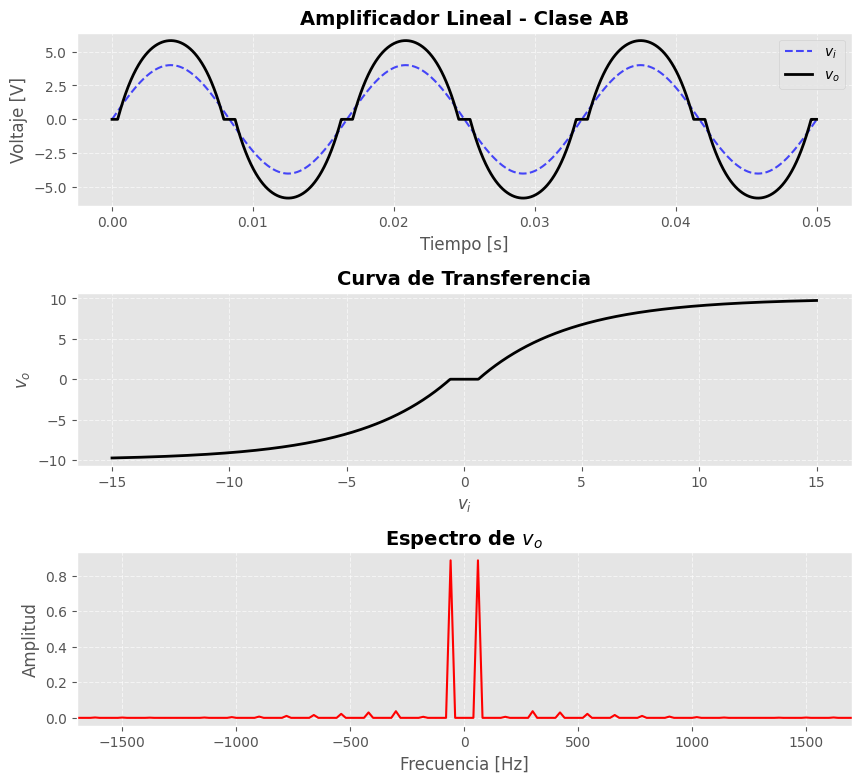

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets, VBox, HBox, Button, FloatText, Dropdown
from IPython.display import display, clear_output

# Diccionario de títulos
titulos = {1: "Clase A", 2: "Clase AB", 3: "Ideal", 4: "Selecciona la clase"}

# Colores para la interfaz
plt.style.use('ggplot') 


def graficar(amplitud, ciclos, tipo):
    try:
        if amplitud <= 0 or ciclos <= 0:
            clear_output(wait=True)
            display(interface)
            print("⚠️ Amplitud y ciclos deben ser mayores que 0.")
            return
        
        puntos = int(1e3)
        frecuencia = 60
        t = np.arange(0, ciclos / frecuencia, 1 / (frecuencia * puntos))
        vi = amplitud * np.sin(2 * np.pi * frecuencia * t)

        if len(vi) == 0:
            clear_output(wait=True)
            display(interface)
            print("⚠️ La señal está vacía. Revisa los valores ingresados.")
            return

        def convert(x, tipo):
            if tipo == 1:
                factor = -np.log(1 - 9 / 10)
                xx = np.abs(x) / (9 / factor)
                y = 10 * (1 - np.exp(-xx))
                y[x < 0] = -y[x < 0]
            elif tipo == 2:
                x = np.copy(x)
                x[np.abs(x) < 0.6] = 0
                x[x >= 0.6] -= 0.6
                x[x <= -0.6] += 0.6
                factor = -np.log(1 - 9 / 10)
                xx = np.abs(x) / (9 / factor)
                y = 10 * (1 - np.exp(-xx))
                y[x < 0] = -y[x < 0]
            else:
                y = x
            return y

        vo = convert(vi, tipo)

        vmax = 15
        curva_in = np.linspace(-vmax, vmax, puntos)
        curva_out = convert(curva_in, tipo)

        fig, axs = plt.subplots(3, 1, figsize=(10, 9), gridspec_kw={'hspace': 0.5})

        axs[0].plot(t, vi, 'b--', label='$v_i$', alpha=0.7)
        axs[0].plot(t, vo, 'k', linewidth=2, label='$v_o$')
        axs[0].set_xlabel('Tiempo [s]', fontsize=12)
        axs[0].set_ylabel('Voltaje [V]', fontsize=12)
        axs[0].set_title(f'Amplificador Lineal - {titulos[tipo]}', fontsize=14, fontweight='bold')
        axs[0].legend(loc='best', fontsize=10)
        axs[0].grid(True, linestyle='--', alpha=0.6)

        axs[1].plot(curva_in, curva_out, 'k', linewidth=2)
        axs[1].set_xlabel('$v_i$', fontsize=12)
        axs[1].set_ylabel('$v_o$', fontsize=12)
        axs[1].set_title('Curva de Transferencia', fontsize=14, fontweight='bold')
        axs[1].grid(True, linestyle='--', alpha=0.6)

        Fsw = frecuencia * puntos
        YY = np.fft.fftshift(np.abs(np.fft.fft(vo)) / len(vo))
        FF = (np.arange(len(vo)) / len(vo) - 0.5) * Fsw
        axs[2].plot(FF, YY * 0.30, 'r', linewidth=1.5)
        axs[2].set_xlabel('Frecuencia [Hz]', fontsize=12)
        axs[2].set_ylabel('Amplitud', fontsize=12)
        axs[2].set_title('Espectro de $v_o$', fontsize=14, fontweight='bold')
        axs[2].grid(True, linestyle='--', alpha=0.6)
        axs[2].set_xlim([-1700, 1700])

        clear_output(wait=True)
        display(interface)
        plt.show()
    except Exception as e:
        clear_output(wait=True)
        display(interface)
        print(f"❌ Error: {e}")

# Widgets estilizados
amplitud_widget = FloatText(value=0, description='Amplitud:', style={'description_width': 'initial'})
ciclos_widget = FloatText(value=0, description='Ciclos:', style={'description_width': 'initial'})
tipo_widget = Dropdown(options=[(v, k) for k, v in titulos.items()], value=4, description='Clase:', style={'description_width': 'initial'})
boton_graficar = Button(description='Iniciar Simulación ▶️', button_style='info')

boton_graficar.style.button_color = 'teal'  # Personalizar color

# Evento del botón
def on_button_click(b):
    graficar(amplitud_widget.value, ciclos_widget.value, tipo_widget.value)

boton_graficar.on_click(on_button_click)

# Layout de la interfaz
interface = VBox([
    widgets.HTML("<h2 style='color: Teal;'>Simulación de Amplificadores (Lineal, Ideal, Conmutado) </h2>"),
    widgets.HTML("<p>Visualiza el comportamiento de tres tipos de amplificadores: lineal ideal, lineal real y conmutado. A través de la gráfica, podemos analizar cómo la señal de salida responde a diferentes entradas y cómo varía en cada configuración. Esto nos ayuda a comparar el rendimiento, la ganancia y la distorsión entre los distintos tipos de amplificadores.</p>"),
    HBox([amplitud_widget, ciclos_widget, tipo_widget]),
    boton_graficar
])

display(interface)

